# ANN Regression [Artificial Neural Network]

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


AT => Temperature \
V => Vaccum \
AP => Pressure \
RH => Humidity

PE => Produced Energy

In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [6]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [8]:
# Split Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
y_test.shape

(1914,)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
import torch
import torch.nn as nn

# Data -> Tensor
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
# .values because y_train is still a panda series. But since we scaled our X_train, it automatically converted into a numpy array!
# .view(-1, 1) [view(row, col)]. Used to change the dimensions of the numpy array
# -1 will chhange into number of rows automatically. and 1 is number of columns

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [12]:
type(X_train_scaled)

numpy.ndarray

In [13]:
type(y_train)

pandas.core.series.Series

In [14]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Deep Learning Model Start

In [16]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd Hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # Output Layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [17]:
import torch.optim as optim

model = ANN()

# Loss, Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [18]:
# Train ANN

train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    # Send Model in training mode
    model.train()
    running_loss = 0.0 # tot. training loss of 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = Labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) # Predicted outputs [This is a forward propagation step]
        loss = criterion(outputs, yb) # Compute Loss
        loss.backward() # Gradients are computed [Backward Propa. Step]
        optimizer.step() # Params update / This optimizer accumulates the params value (Not a pro)
        
        running_loss += loss.item() # Loss is a tensor value so we convert to python float value

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # No gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1} / {epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") # .pt or .pth

epoch 1 / 100 ==> train loss = 205196.68404947917 & val loss = 202399.109375
epoch 2 / 100 ==> train loss = 194624.17486979166 & val loss = 183108.578125
epoch 3 / 100 ==> train loss = 164977.95052083334 & val loss = 144888.53125
epoch 4 / 100 ==> train loss = 123817.96901041667 & val loss = 104923.2890625
epoch 5 / 100 ==> train loss = 88337.02748209635 & val loss = 75573.5859375
epoch 6 / 100 ==> train loss = 64632.6791015625 & val loss = 54660.60546875
epoch 7 / 100 ==> train loss = 44185.93400878906 & val loss = 34397.296875
epoch 8 / 100 ==> train loss = 25284.624584960937 & val loss = 17351.18359375
epoch 9 / 100 ==> train loss = 11516.542547607422 & val loss = 7080.28076171875
epoch 10 / 100 ==> train loss = 4849.5429016113285 & val loss = 3418.469482421875
epoch 11 / 100 ==> train loss = 2830.4148610432944 & val loss = 2397.763916015625
epoch 12 / 100 ==> train loss = 2111.6195241292316 & val loss = 1867.3826904296875
epoch 13 / 100 ==> train loss = 1669.6207778930664 & val los

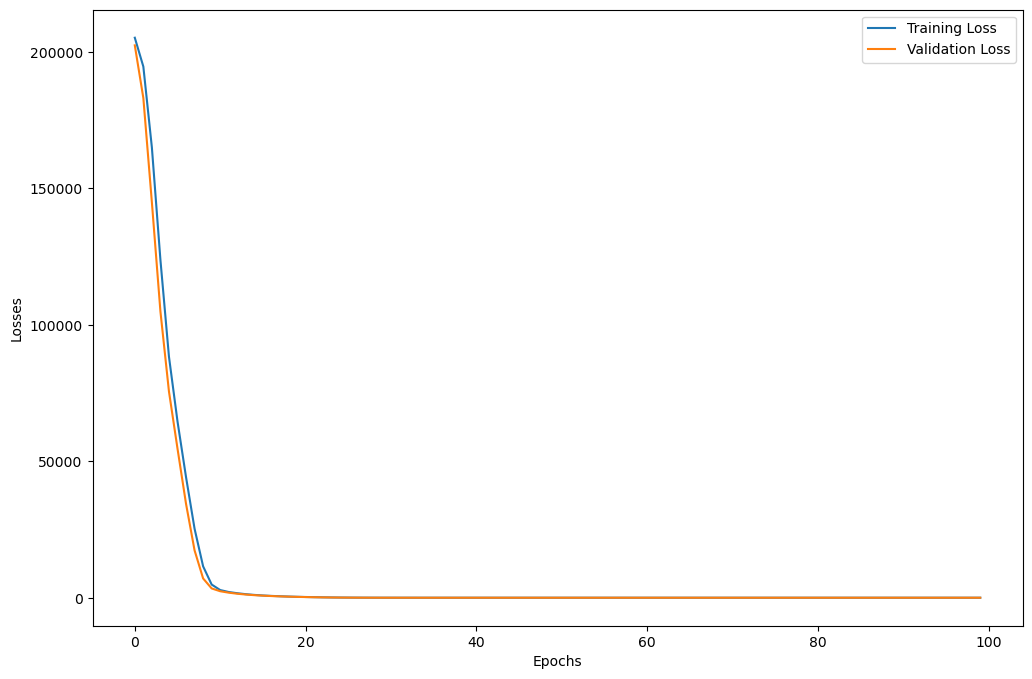

In [19]:
import matplotlib.pyplot as plt

loss_df = pd. DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [20]:
# Loading our best Model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [21]:
# Evaluate our model

model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = criterion(train_pred, y_train_tensor)
    test_mse_loss = criterion(test_pred, y_test_tensor)

print("Training MSE: ", train_mse_loss.item())
print("Testing MSE: ", test_mse_loss.item())

Training MSE:  21.299320220947266
Testing MSE:  19.565065383911133


In [22]:
from sklearn.metrics import r2_score

print("r2_score: ", r2_score(y_test, test_pred))

r2_score:  0.9316251448260625


In [24]:
predicted_df = pd.DataFrame(test_pred.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.732269,433.27
1,437.161499,438.16
2,461.191467,458.42
3,475.679810,480.82
4,435.985565,441.41
...,...,...
1909,451.184143,456.70
1910,432.073181,438.04
1911,467.302002,467.80
1912,431.531433,437.14
